In [1]:
import numpy as np
import matplotlib.pyplot as plt
import odl

import sys
sys.path.append("..")

from src.tomo import (
    make_space_2d,
    shepp_logan_2d,
    parallel_geom_2d,
    ray_transform_2d,
    reconstruct_bp,
    reconstruct_fbp,
)

xmin, xmax, ymin, ymax = -20, 20, -20, 20
Nx, Ny = 100, 100
space = make_space_2d(Nx=Nx, Ny=Ny, domain=[xmin, xmax, ymin, ymax])
phantom = shepp_logan_2d(space)
phantom_np = phantom.asarray()

angular_coverage=(-90,90)
step = 1

# detector half-width should be at least the half-diagonal of the reconstruction box
r = np.sqrt((0.5*(xmax - xmin))**2 + (0.5*(ymax - ymin))**2)
det_range = (-r, r)

det_count = int(np.ceil(1.5 * np.sqrt(Nx**2 + Ny**2)))

geom = parallel_geom_2d(angular_coverage=angular_coverage, step=step, 
                        det_range=det_range, det_count=det_count)
A = ray_transform_2d(space, geom)
data_space = A.range

sinogram = A(phantom)

from src.tomo import add_relative_gaussian_noise
sino_noisy = add_relative_gaussian_noise(sinogram, rel_level=0.1)  # 10% noise



/home/ahopkins/KTH_TTMAM/MEX/odl_xray/venv/lib/python3.10/site-packages/odl/util/utility.py:1398: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_requirements


**Find best frequency filter for noise level (best FBP solution)**
* Measured in relative $L^2$-error against the true phantom

In [2]:
from src.metrics import rel_l2_err
# Find the best FBP solution by looping over all filters, measured by relative L2
error = np.inf
for filter in ["Ram-Lak", "Shepp-Logan", "Cosine", "Hamming", "Hann"]:
    temp = reconstruct_fbp(sino_noisy, A, filter_name=filter)
    temp = temp.asarray()
    temp_error = rel_l2_err(x=temp, xtrue=phantom_np)
    if temp_error < error:
        fbp_best = temp
        error = temp_error
        best_filter = filter

# Reference solution is the FBP with ramp filter (Ram-Lak)
fbp_ref = reconstruct_fbp(sino_noisy, A, filter_name="Ram-Lak")
fbp_ref = fbp_ref.asarray()

In [3]:
import odl, inspect
import odl.tomo.analytic.filtered_back_projection as fbpmod
print(odl.__version__)
print(inspect.getsource(fbpmod._fbp_filter))


0.8.3
def _fbp_filter(norm_freq, filter_type, frequency_scaling):
    """Create a smoothing filter for FBP.

    Parameters
    ----------
    norm_freq : `array-like`
        Frequencies normalized to lie in the interval [0, 1].
    filter_type : {'Ram-Lak', 'Shepp-Logan', 'Cosine', 'Hamming', 'Hann',
                   callable}
        The type of filter to be used.
        If a string is given, use one of the standard filters with that name.
        A callable should take an array of values in [0, 1] and return the
        filter for these frequencies.
    frequency_scaling : float
        Scaling of the frequencies for the filter. All frequencies are scaled
        by this number, any relative frequency above ``frequency_scaling`` is
        set to 0.

    Returns
    -------
    smoothing_filter : `numpy.ndarray`

    Examples
    --------
    Create an FBP filter

    >>> norm_freq = np.linspace(0, 1, 10)
    >>> filt = _fbp_filter(norm_freq,
    ...                    filter_ty

### Fixing the ODL internal _fbp_filter
* Fixing it so that it accepts a custom filter

In [4]:
def _fbp_filter_patched(norm_freq, filter_type, frequency_scaling):
    """Create a smoothing filter for FBP.

    Parameters
    ----------
    norm_freq : `array-like`
        Frequencies normalized to lie in the interval [0, 1].
    filter_type : {'Ram-Lak', 'Shepp-Logan', 'Cosine', 'Hamming', 'Hann',
                   callable}
        The type of filter to be used.
        If a string is given, use one of the standard filters with that name.
        A callable should take an array of values in [0, 1] and return the
        filter for these frequencies.
    frequency_scaling : float
        Scaling of the frequencies for the filter. All frequencies are scaled
        by this number, any relative frequency above ``frequency_scaling`` is
        set to 0.

    Returns
    -------
    smoothing_filter : `numpy.ndarray`

    Examples
    --------
    Create an FBP filter

    >>> norm_freq = np.linspace(0, 1, 10)
    >>> filt = _fbp_filter(norm_freq,
    ...                    filter_type='Hann',
    ...                    frequency_scaling=0.8)
    """
    # filter_type, filter_type_in = str(filter_type).lower(), filter_type
    filter_type_in = filter_type    # Add this for error message
    if callable(filter_type):
        filt = filter_type(norm_freq)
    else:   # add else here for string-based call (e.g. "hann")
        filter_type = str(filter_type).lower()
        if filter_type == 'ram-lak':
            filt = np.copy(norm_freq)
        elif filter_type == 'shepp-logan':
            filt = norm_freq * np.sinc(norm_freq / (2 * frequency_scaling))
        elif filter_type == 'cosine':
            filt = norm_freq * np.cos(norm_freq * np.pi / (2 * frequency_scaling))
        elif filter_type == 'hamming':
            filt = norm_freq * (
                0.54 + 0.46 * np.cos(norm_freq * np.pi / (frequency_scaling)))
        elif filter_type == 'hann':
            filt = norm_freq * (
                np.cos(norm_freq * np.pi / (2 * frequency_scaling)) ** 2)
        else:
            raise ValueError('unknown `filter_type` ({})'
                            ''.format(filter_type_in))

    indicator = (norm_freq <= frequency_scaling)
    filt *= indicator
    return filt


# Patch
fbpmod._fbp_filter = _fbp_filter_patched


### Creating the SIAC filter for FBP with ramp

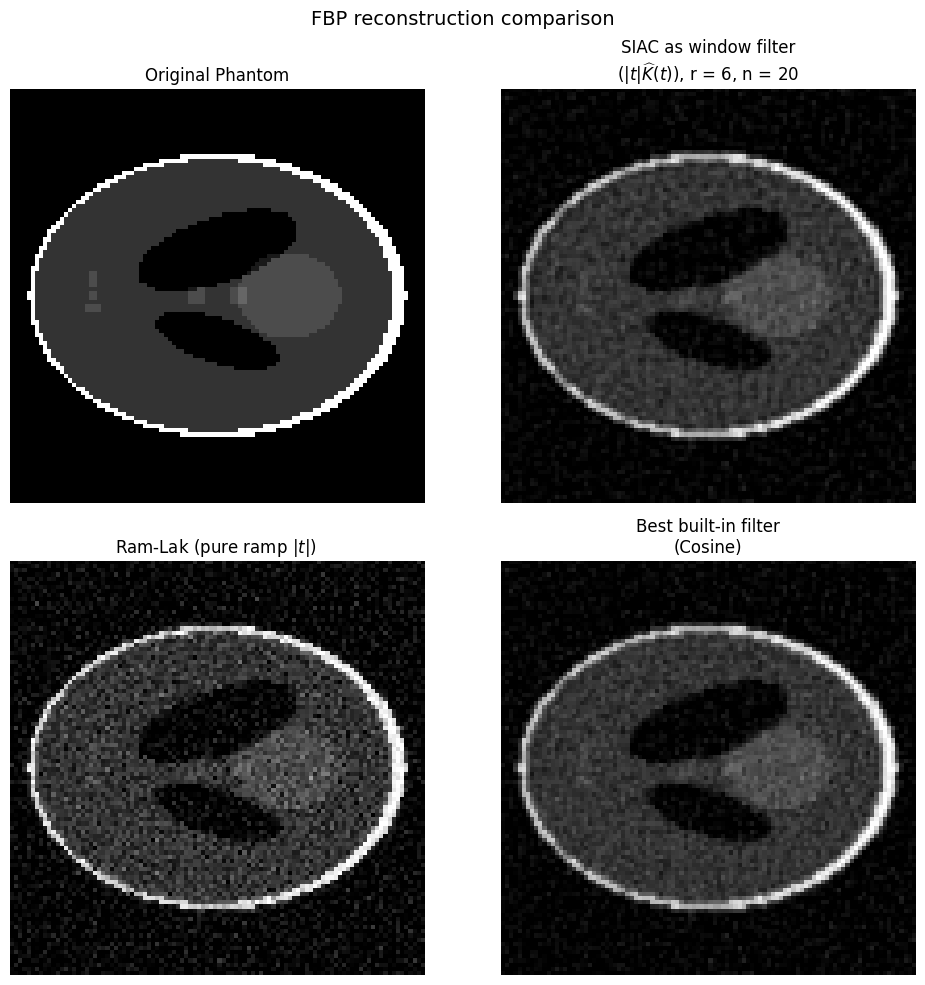

In [ ]:
from src.siac_fourier import siac_cgam

def siac_filter_odl(moments, BSorder, include_ramp=True):
    cgam = siac_cgam(moments, BSorder)

    def filt(t):
        t = np.asarray(t, dtype=float)
        t = np.clip(t, 0.0, 1.0)

        # Dimensionless frequency
        w = np.pi * t

        # Cosine series
        cterm = cgam[0] * np.ones_like(w)
        for gamma in range(1, len(cgam)):
            cterm += 2.0 * cgam[gamma] * np.cos(gamma * w)

        # B-spline factor
        sinc_term = np.sinc(w / (2.0 * np.pi)) ** BSorder

        Khat = sinc_term * cterm

        if include_ramp:
            return t * Khat   # Ram-Lak x SIAC window
        else:
            return Khat #1-Khat       # SIAC window only
        
    return filt


fbp_best = odl.tomo.fbp_op(
    A,
    filter_type=best_filter,
    padding=True,
    frequency_scaling=1.0
)

moments = 6
BSorder = 20

fbp_siac = odl.tomo.fbp_op(
    A, 
    filter_type = siac_filter_odl(moments=moments, BSorder=BSorder, include_ramp=True), 
    padding=True, 
    frequency_scaling=1.0
)

# make subplots
fbp_img_SIAC = fbp_siac(sino_noisy).asarray()
fbp_img_best = fbp_best(sino_noisy).asarray()
fbp_img_ref = fbp_ref


fig, axes = plt.subplots(2, 2, figsize=(10, 10))


vmin = phantom_np.min()
vmax = phantom_np.max()

# --- SIAC-based reconstructions ---
axes[0, 0].imshow(phantom_np, cmap="gray", vmin=vmin, vmax=vmax)
axes[0, 0].set_title("Original Phantom")
axes[0, 0].axis("off")

axes[0, 1].imshow(fbp_img_SIAC, cmap="gray", vmin=vmin, vmax=vmax)
axes[0, 1].set_title(f"SIAC as window filter\n($|t|\widehat K(t)$), r = {moments}, n = {BSorder}")
axes[0, 1].axis("off")

# --- Reference / baseline reconstructions ---
axes[1, 0].imshow(fbp_img_ref, cmap="gray", vmin=vmin, vmax=vmax)
axes[1, 0].set_title("Ram-Lak (pure ramp $|t|$) ")
axes[1, 0].axis("off")

axes[1, 1].imshow(fbp_img_best, cmap="gray", vmin=vmin, vmax=vmax)
axes[1, 1].set_title(f"Best built-in filter\n({best_filter})")
axes[1, 1].axis("off")

fig.suptitle("FBP reconstruction comparison", fontsize=14)
plt.tight_layout()
plt.show()

plt.show()  # to not get duplicated plots for the last one


### Solving Regularized Problems with Tikhonov, TV, $\mathrm{TGV}^2$ and SIAC

* To obtain good results, we use Morozovs discrepenacy principle to find good values of the regularization strength $\alpha$ for the solutions. This can be done since the noise level is known (synthetic phantoms).

**Find noise level**
$$
\delta = \|\varepsilon\|_2
$$
With the model
$$
    \mathrm{data} = Ax^\dagger + \epsilon
$$
where $x^\dagger$ is the ground truth image (phantom)

In [ ]:
data = sino_noisy

print(f"||data|| = {data.norm()}")
delta = (data - sinogram).norm()
print(f"delta = {delta}")

||data|| = 61.52651545790809
$\delta$ = 6.124452970124198


In [7]:
from src.regularizations import solve_siac, solve_tgv2, solve_tikhonov, solve_tv, choose_alpha_morozov

moments = 2
BSorder = 3
# SIAC
alpha_siac, x_siac = choose_alpha_morozov(
    reconstruct=lambda a: solve_siac(A, data, alpha=a, moments=moments, 
                                     BSorder=BSorder, niter=80),
    A=A, data=data, delta=delta
)
print(f"Best alpha for SIAC = {alpha_siac} \n With r = {moments}, n = {BSorder}")

Best alpha for SIAC = 48.696752516586315 
 With r = 2, n = 3


In [8]:
from src.regularizations import solve_siac_L1

x0 = reconstruct_fbp(sino_noisy, A, filter_name="Ram-Lak")

moments_l1 = 2
BSorder_l1 = 4
alpha_siac_l1, x_siac_l1 = choose_alpha_morozov(
    reconstruct=lambda a: solve_siac_L1(A, data, alpha=a, moments=moments_l1, 
                                        BSorder=BSorder_l1, niter=200, x0=x0),
    A=A, data=data, delta=delta
)
print(f"Best alpha for L1 SIAC = {alpha_siac_l1} \n With r = {moments_l1}, n = {BSorder_l1}")

Best alpha for L1 SIAC = 5.623413251903491 
 With r = 2, n = 4


In [9]:

# Tikhonov
alpha_tik, x_tik = choose_alpha_morozov(
    reconstruct=lambda a: solve_tikhonov(A, data, alpha=a, niter=80),
    A=A, data=data, delta=delta
)
print(f"Best alpha for Tikhonov = {alpha_tik}")

Best alpha for Tikhonov = 0.7773650302387759


In [10]:

# Allow for an initial guess for TV and TGV^2
x0 = reconstruct_fbp(sino_noisy, A, filter_name="Ram-Lak")
# TV
alpha_tv, x_tv = choose_alpha_morozov(
    reconstruct=lambda a: solve_tv(A, data, alpha=a, niter=300, x0=x0, 
                                   isotropic=True),
    A=A, data=data, delta=delta
)
print(f"Best alpha for TV = {alpha_tv}")

Best alpha for TV = 0.07498942093324558


In [11]:

# TGV^2
alpha_tgv, x_tgv = choose_alpha_morozov(
    reconstruct=lambda a: solve_tgv2(A, data, alpha=a, beta=1.0, 
                                     niter=400, x0=x0),
    A=A, data=data, delta=delta
)
print(f"Best alpha for TGV^2 = {alpha_tgv}")


Best alpha for TGV^2 = 0.07498942093324558


In [12]:
from src.regularizations import solve_siac_grad
moments_siac_grad = 4
BSorder_siac_grad= 6
# SIAC on gradient
alpha_siac_grad, x_siac_grad = choose_alpha_morozov(
    reconstruct=lambda a: solve_siac_grad(A, data, alpha=a, moments=moments_siac_grad,
                                        BSorder=BSorder_siac_grad, 
                                        niter=300, x0=x0),
    A=A, data=data, delta=delta
)
print(f"Best alpha for SIAC on gradient = {alpha_siac_grad}")

Best alpha for SIAC on gradient = 0.1539926526059492


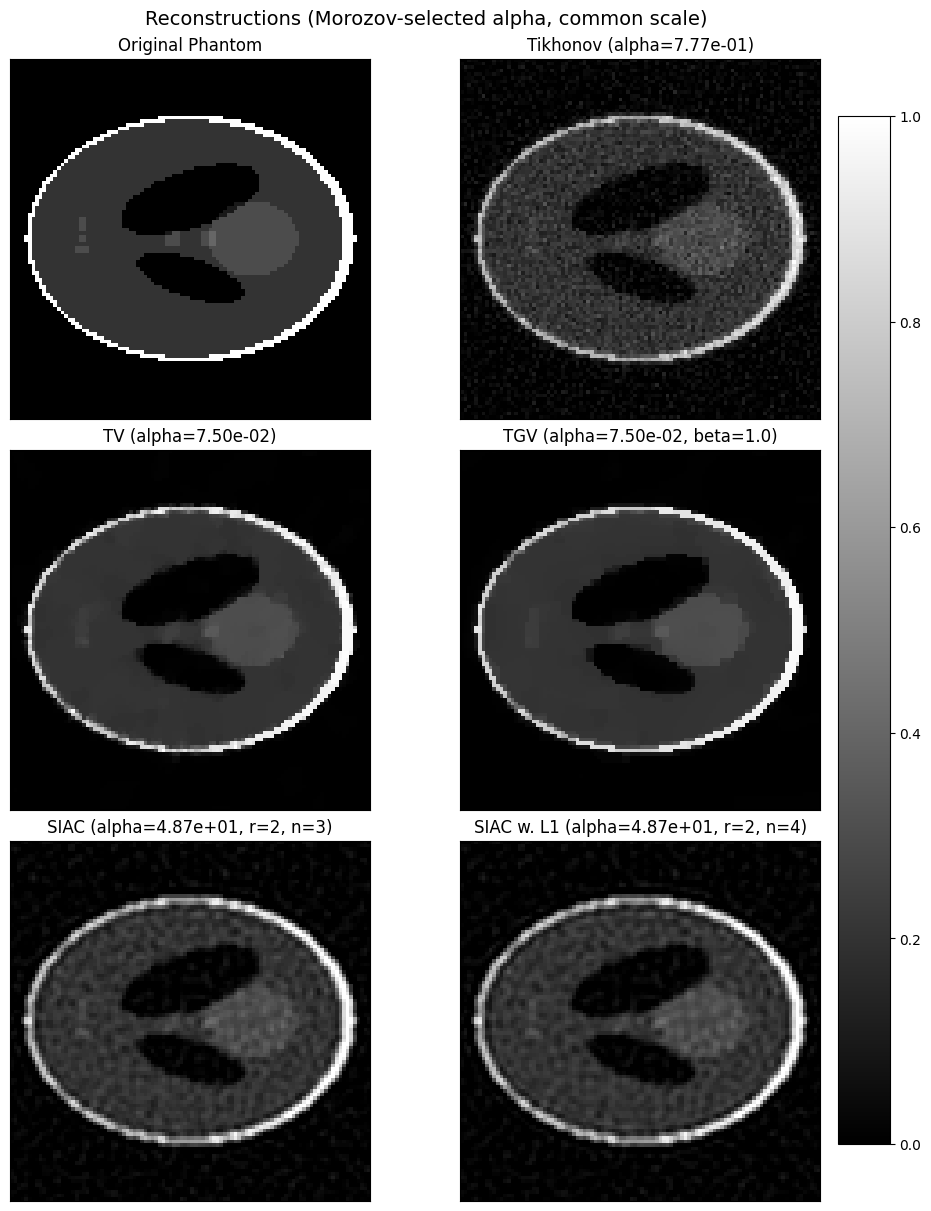

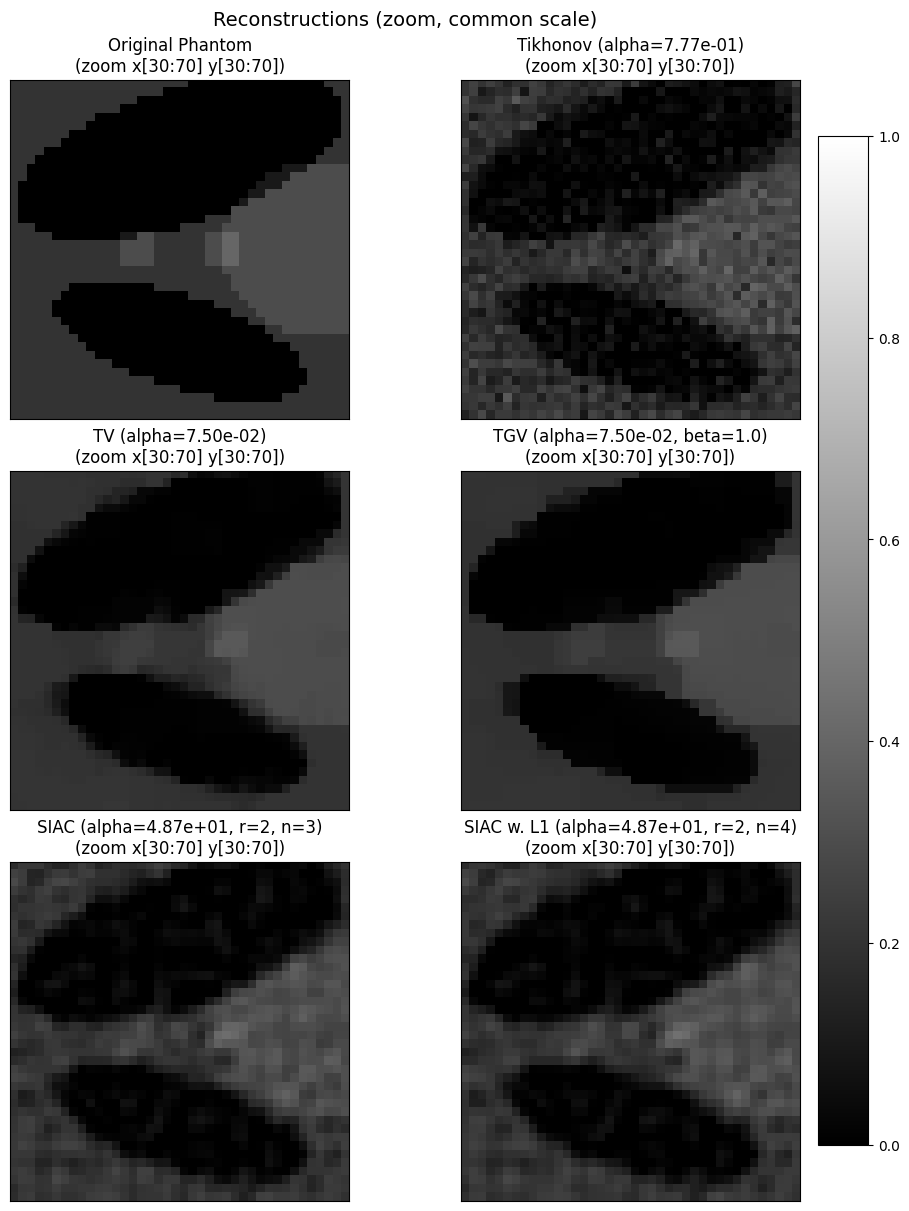

(<Figure size 1000x1200 with 7 Axes>, <Figure size 1000x1200 with 7 Axes>)

In [ ]:
recons = [phantom, x_tik, x_tv, x_tgv, x_siac, x_siac_l1]
titles = [
    f"Original Phantom",
    f"Tikhonov (alpha={alpha_tik:.2e})",
    f"TV (alpha={alpha_tv:.2e})",
    f"TGV (alpha={alpha_tgv:.2e}, beta=1.0)",
    f"SIAC (alpha={alpha_siac:.2e}, r={moments}, n={BSorder})",
    f"SIAC w. L1 (alpha={alpha_siac:.2e}, r={moments_l1}, n={BSorder_l1})"
]

from src.helpers import plot_recon_grid_3x2_with_zoom
plot_recon_grid_3x2_with_zoom(
    recons, titles,
    suptitle_full="Reconstructions (Morozov-selected alpha, common scale)",
    suptitle_zoom="Reconstructions (zoom, common scale)",
    zoom_frac=(0.30, 0.70, 0.30, 0.70),
)

In [15]:
import time

space = A.domain

# SIAC
t0 = time.perf_counter()
x_siac = solve_siac(A, data, alpha=alpha_siac,
                    moments=moments, BSorder=BSorder, niter=200)
t_siac = time.perf_counter() - t0

# Tikhonov 
t0 = time.perf_counter()
x_tik = solve_tikhonov(A, data, alpha=alpha_tik, niter=200)
t_tik = time.perf_counter() - t0

# TV
t0 = time.perf_counter()
x_tv = solve_tv(A, data, alpha=alpha_tv, niter=400)
t_tv = time.perf_counter() - t0

# TGV2: keep full state (x, y)
t0 = time.perf_counter()
x_tgv_state = solve_tgv2(A, data, alpha=alpha_tgv, niter=400)
t_tgv = time.perf_counter() - t0

x_tgv = x_tgv_state[0]

# SIAC L1
t0 = time.perf_counter()
x_siac_l1 = solve_siac(A, data, alpha=alpha_siac_l1,
                    moments=moments_l1, BSorder=BSorder_l1, niter=400)
t_siac_l1 = time.perf_counter() - t0

In [16]:
# SIAC on gradient
t0 = time.perf_counter()
x_siac_grad = solve_siac_grad(A, data, alpha=alpha_siac_grad, moments=moments_siac_grad,
                                        BSorder=BSorder_siac_grad, 
                                        niter=400)
t_siac_grad = time.perf_counter() - t0


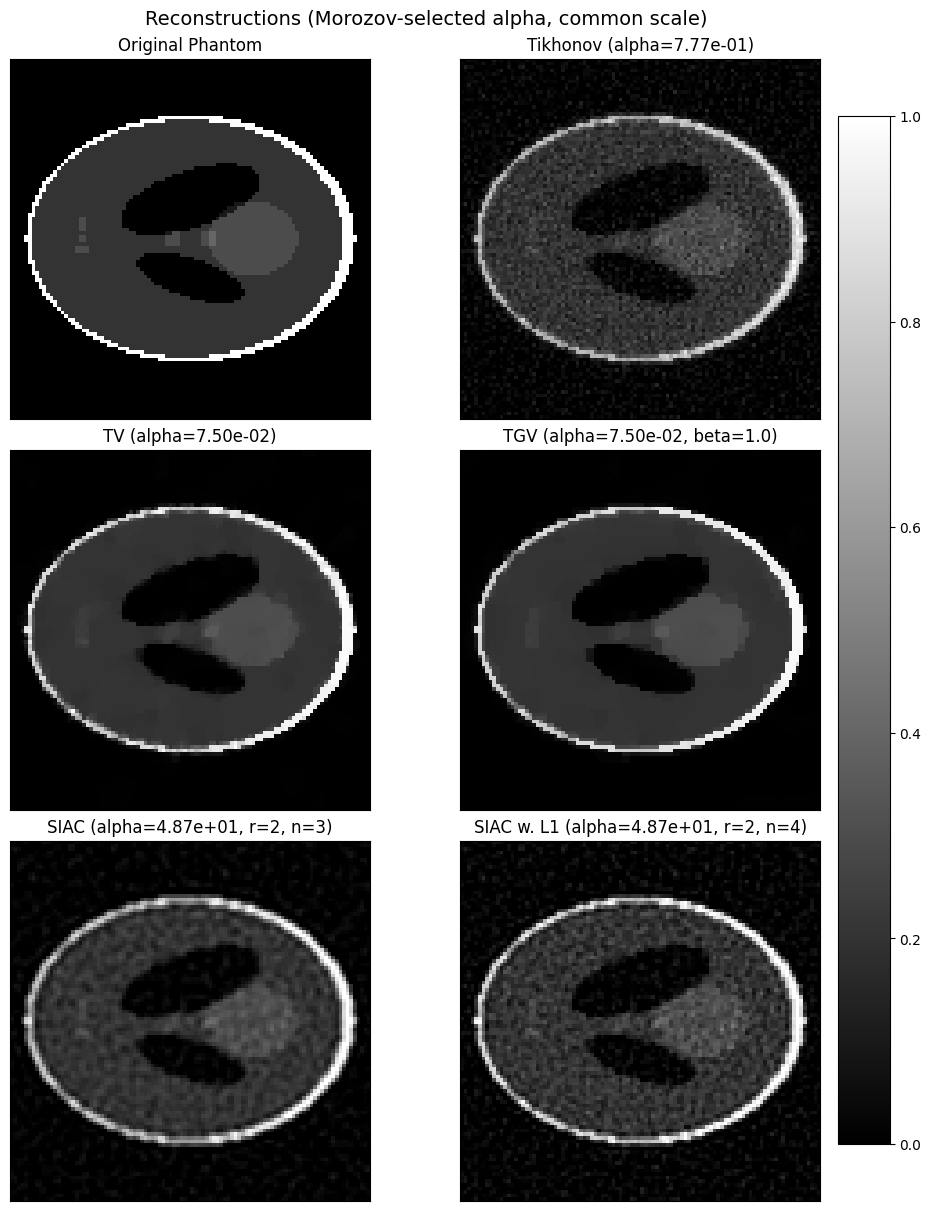

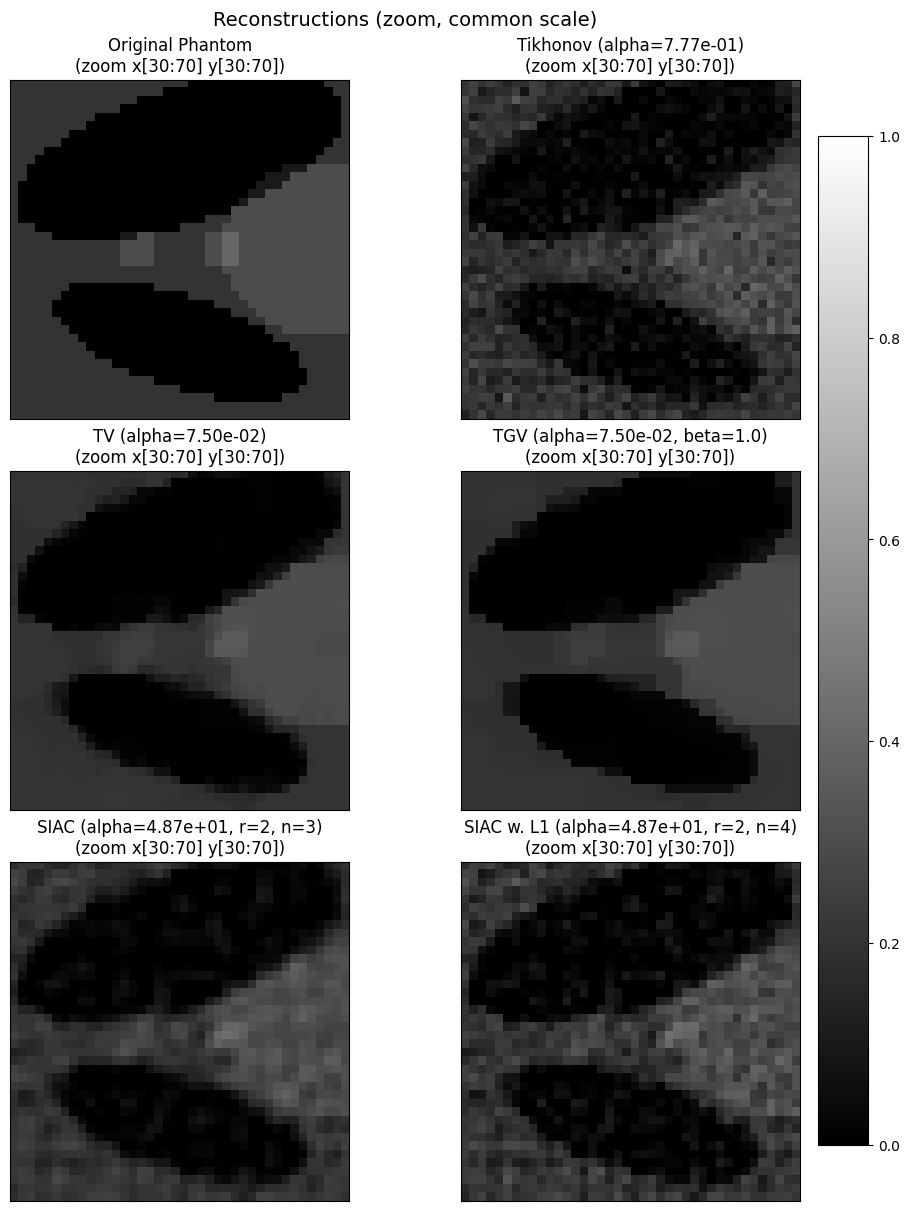

(<Figure size 1000x1200 with 7 Axes>, <Figure size 1000x1200 with 7 Axes>)

In [20]:
recons = [phantom, x_tik, x_tv, x_tgv, x_siac, x_siac_l1]
titles = [
    f"Original Phantom",
    f"Tikhonov (alpha={alpha_tik:.2e})",
    f"TV (alpha={alpha_tv:.2e})",
    f"TGV (alpha={alpha_tgv:.2e}, beta=1.0)",
    f"SIAC (alpha={alpha_siac:.2e}, r={moments}, n={BSorder})",
    f"SIAC w. L1 (alpha={alpha_siac:.2e}, r={moments_l1}, n={BSorder_l1})"
]

plot_recon_grid_3x2_with_zoom(
    recons, titles,
    suptitle_full="Reconstructions (Morozov-selected alpha, common scale)",
    suptitle_zoom="Reconstructions (zoom, common scale)",
    zoom_frac=(0.30, 0.70, 0.30, 0.70),
)

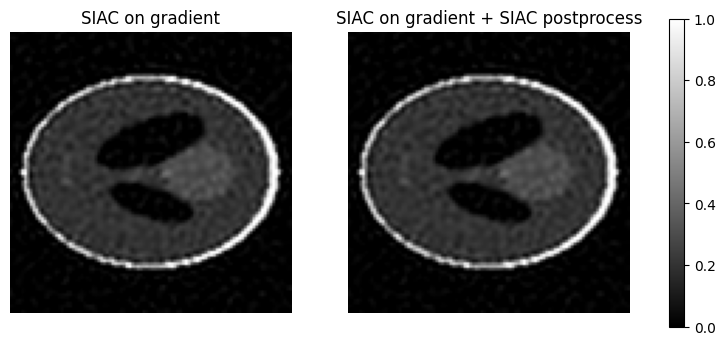

SIAC-grad error: 2.956192779541016
SIAC-grad + SIAC error: 3.073456954956055


In [ ]:
# Postprocess it with SIAC again
dx, dy = space.cell_sides           # physical grid spacing (x, y)
x_siac_grad_np = x_siac_grad.asarray()

moments_pp = 4
BSorder_pp = 4

from src.siac_fourier import apply_siac_fft_nd
# Apply SIAC again to counteract oscillatory artifacts
x_siac_grad_np_pp = apply_siac_fft_nd(arr=x_siac_grad_np, 
                                      h_per_axis=(dy, dx), 
                                      axes=(0, 1), 
                                      moments=moments_pp, 
                                      BSorder=BSorder_pp, 
                                      pad_mode="reflect")
x_siac_grad_pp = space.element(x_siac_grad_np_pp)

vmin = phantom_np.min()
vmax = phantom_np.max()

fig, ax = plt.subplots(1, 2, figsize=(10,5))

im0 = ax[0].imshow(x_siac_grad.asarray(), cmap="gray", vmin=vmin, vmax=vmax)
ax[0].set_title("SIAC on gradient")
ax[0].axis("off")

im1 = ax[1].imshow(x_siac_grad_pp.asarray(), cmap="gray", vmin=vmin, vmax=vmax)
ax[1].set_title("SIAC on gradient + SIAC postprocess")
ax[1].axis("off")

fig.colorbar(im0, ax=ax, shrink=0.8)

plt.show()

print("SIAC-grad error:", (x_siac_grad - phantom).norm())
print("SIAC-grad + SIAC error:", (x_siac_grad_pp - phantom).norm())

In [ ]:
# Recommended saving for report:

# save_and_plot_image_with_zoom(
#     x_siac_grad,
#     save_path="figures/siac_grad.png",
#     cmap="gray",
#     vmin=0.0,
#     vmax=1.0,
#     raw=True,
#     show=True,
#     save=True,
# )